# 02 — Synthetic Bank Loans and Necessary Variables

## Meet the synthetic loan book

This notebook makes the complete loan-level dataset visible. It contains different products and the contractual, borrower, collateral, rating, recovery and maturity fields required later.

Balances and commitments determine EAD. Borrower and collateral fields determine classification and risk weights. Rating, recovery and maturity fields determine the IRB capital function.

### Fields that appear in the loan data

| Term | Simple meaning |
|---|---|
| Drawn amount | the amount already borrowed |
| Undrawn amount | the unused portion of a committed limit |
| Commitment type | the contractual category used to select a CCF |
| Revolving facility | credit that may be borrowed, repaid and borrowed again within a limit |
| Synthetic | artificial and reproducible rather than real customer data |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display as notebook_display
from pandas.io.formats.style import Styler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from basel_credit_risk.config import load_all_config

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)


def display(*objects, **kwargs):
    # Show complete table text and wrap long descriptions in saved notebook output.
    wrapped_objects = []
    for displayed_object in objects:
        if isinstance(displayed_object, pd.DataFrame):
            displayed_object = displayed_object.style
        if isinstance(displayed_object, Styler):
            displayed_object = displayed_object.set_properties(**{
                "white-space": "normal",
                "overflow-wrap": "anywhere",
                "text-align": "left",
                "vertical-align": "top",
                "max-width": "420px",
            }).set_table_styles([
                {"selector": "table", "props": [("width", "100%"), ("table-layout", "auto")]},
                {"selector": "th", "props": [
                    ("white-space", "normal"),
                    ("overflow-wrap", "anywhere"),
                    ("word-break", "break-word"),
                    ("text-align", "left"),
                    ("vertical-align", "top"),
                    ("max-width", "180px"),
                ]},
            ], overwrite=False)
        wrapped_objects.append(displayed_object)
    return notebook_display(*wrapped_objects, **kwargs)

configs = load_all_config(ROOT / "config")
raw = pd.read_csv(ROOT / "data/generated/current_portfolio.csv.gz", low_memory=False)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)

print(f"Portfolio represented below: {len(loans):,} synthetic loan-level exposures")

Portfolio represented below: 30,000 synthetic loan-level exposures


> The loan records, balances, ratings, defaults, collateral values and recoveries are synthetic. A bank would obtain these fields from governed lending, limit, collateral, rating, default and recovery systems and reconcile them to finance records.

## One representative loan from every segment

The sample prevents the backend file from remaining invisible. Monetary columns are displayed in INR crore. Revolving facilities show both drawn and undrawn amounts; term products generally have no unused commitment.

In [2]:
sample_columns = [
    "exposure_id", "segment", "product_type", "borrower_type",
    "internal_grade", "outstanding_balance", "credit_limit", "undrawn_amount",
    "commitment_type", "revolving_flag", "collateral_type",
    "property_value_current", "contractual_maturity_years", "default_flag",
]
examples = (
    raw.sort_values(["segment", "exposure_id"])
    .groupby("segment", as_index=False)
    .first()[sample_columns]
    .copy()
)
money_columns = ["outstanding_balance", "credit_limit", "undrawn_amount", "property_value_current"]
examples[money_columns] /= CRORE
examples = examples.rename(columns={column: f"{column} (INR crore)" for column in money_columns})
display(examples)

,exposure_id,segment,product_type,borrower_type,internal_grade,outstanding_balance (INR crore),credit_limit (INR crore),undrawn_amount (INR crore),commitment_type,revolving_flag,collateral_type,property_value_current (INR crore),contractual_maturity_years,default_flag
0,EXP-0027601,bank,bank_loan,bank,AAA,49.550446,75.248618,25.698172,other_commitment,True,cash,0.000000,6.157742,0
1,EXP-0021601,credit_card,credit_card,individual,BB,0.005970,0.007266,0.001296,unconditionally_cancellable,True,none,0.000000,4.364230,0
2,EXP-0009601,large_corporate,corporate_revolver,large_corporate,B,30.558323,39.297382,8.739060,other_commitment,True,commercial_property,27.896334,3.517102,1
3,EXP-0000001,mortgage,mortgage,individual,BB,0.207355,0.207355,0.000000,no_commitment,False,residential_property,0.287241,1.384805,0
4,EXP-0029401,other,other,other,BBB,0.512085,1.657564,1.145479,other_commitment,True,none,0.000000,1.148027,0
5,EXP-0015601,personal_loan,personal_loan,individual,BB,0.100463,0.100463,0.000000,no_commitment,False,none,0.000000,3.185453,0
6,EXP-0012601,sme,sme_revolver,sme,BB,7.046056,10.413799,3.367743,other_commitment,True,none,0.000000,2.821466,0
7,EXP-0028651,sovereign,sovereign_bond,sovereign,AA,59.488840,59.488840,0.000000,no_commitment,False,none,0.000000,0.425651,0


The table shows why one uniform rule is insufficient. A corporate revolver and credit card both have undrawn capacity, but their borrower type and commitment terms differ. A mortgage has property values needed for LTV. A sovereign bond has no retail or property test.

## Dataset variable groups

The major dataset contains inputs as well as calculated fields. The table below groups the most important variables by the question they answer.

In [3]:
variable_groups = pd.DataFrame({
    "Question": ["Which record?", "Who owes the money?", "What is the contract?", "What protection exists?", "What is the credit quality?", "What is needed for IRB recovery?"],
    "Important variables": [
        "exposure_id, borrower_id, reporting_date",
        "borrower_type, is_sme, managed_as_retail, annual_revenue",
        "product_type, outstanding, limit, undrawn, commitment_type, maturity",
        "collateral_type, property values, guarantee, senior lien",
        "internal grade, external rating, default flag, days past due",
        "normal/downturn recovery rates, costs, recovery time and LGD",
    ],
})
display(variable_groups)

,Question,Important variables
0,Which record?,"exposure_id, borrower_id, reporting_date"
1,Who owes the money?,"borrower_type, is_sme, managed_as_retail, annual_revenue"
2,What is the contract?,"product_type, outstanding, limit, undrawn, commitment_type, maturity"
3,What protection exists?,"collateral_type, property values, guarantee, senior lien"
4,What is the credit quality?,"internal grade, external rating, default flag, days past due"
5,What is needed for IRB recovery?,"normal/downturn recovery rates, costs, recovery time and LGD"


Every later parameter can therefore be traced to a loan characteristic. Regulatory outputs such as CCF, EAD, risk weight, PD, downturn LGD, correlation, K and RWA are added to the calculated loan file rather than hidden in a separate aggregate table.

## Record mix and monetary size

The left measure counts loans. The right measure sums drawn balances. Corporate and sovereign records can be few but large, while retail segments can be numerous but individually small.

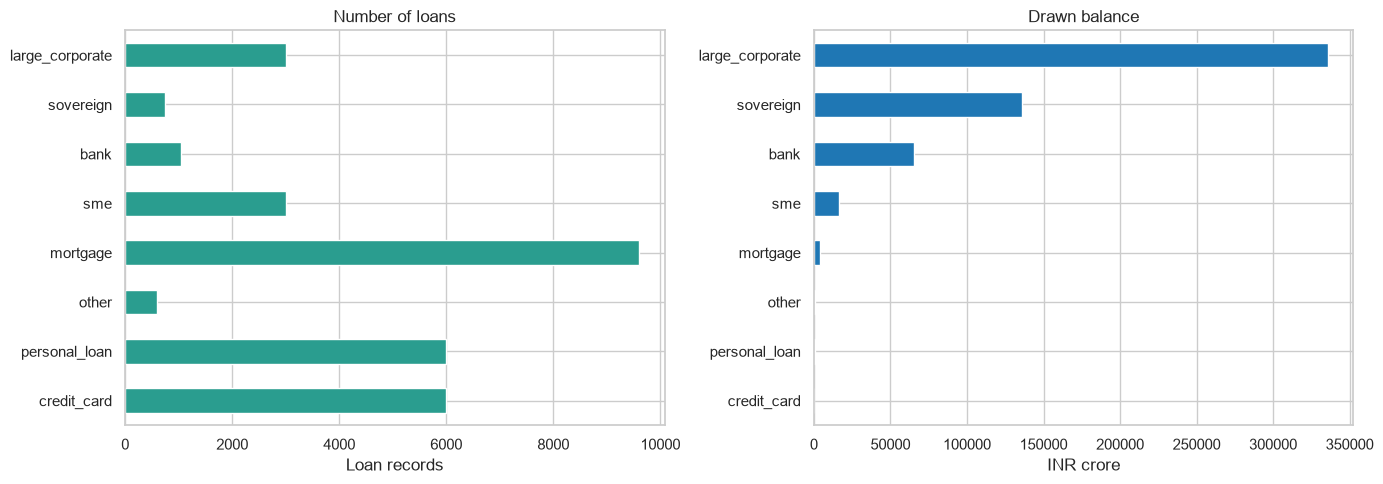

In [4]:
portfolio_mix = raw.groupby("segment").agg(
    loan_count=("exposure_id", "count"),
    drawn_balance=("outstanding_balance", "sum"),
).sort_values("drawn_balance")
portfolio_mix["drawn_balance"] /= CRORE

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
portfolio_mix["loan_count"].plot.barh(ax=axes[0], color=COLORS[2], title="Number of loans")
portfolio_mix["drawn_balance"].plot.barh(ax=axes[1], color=COLORS[1], title="Drawn balance")
axes[0].set_xlabel("Loan records")
axes[1].set_xlabel("INR crore")
axes[0].set_ylabel("")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

Record count reflects operating volume. Drawn balance is closer to financial size, but it is still not EAD because undrawn commitments have not yet been converted. The next stages perform classification and EAD separately.

The bank now contains 30,000 visible loan-level records with the variables needed for both approaches. No aggregate risk weight has been assumed at this stage.